In [1]:
# calling important libraries

import pandas as pd

icpms = pd.read_excel('/content/dataset icpms(1).xlsx', sheet_name='icpms')

# **Logistic regression with k-fold cross validation**

Fold 1 Accuracy: 0.7895
Fold 1 Metrics:
  Accuracy: 0.7895
  Precision: 0.8289
  Recall: 0.7895
  F1-Score: 0.7759
  Confusion Matrix:
[[6 1 0]
 [0 6 0]
 [2 1 3]]

Fold 2 Accuracy: 0.6316
Fold 2 Metrics:
  Accuracy: 0.6316
  Precision: 0.6491
  Recall: 0.6316
  F1-Score: 0.6378
  Confusion Matrix:
[[4 1 2]
 [2 5 0]
 [2 0 3]]

Fold 3 Accuracy: 0.8421
Fold 3 Metrics:
  Accuracy: 0.8421
  Precision: 0.8895
  Recall: 0.8421
  F1-Score: 0.8409
  Confusion Matrix:
[[7 0 0]
 [1 6 0]
 [2 0 3]]

Fold 4 Accuracy: 0.8947
Fold 4 Metrics:
  Accuracy: 0.8947
  Precision: 0.8947
  Recall: 0.8947
  F1-Score: 0.8947
  Confusion Matrix:
[[5 0 1]
 [0 7 0]
 [1 0 5]]

Fold 5 Accuracy: 0.9444
Fold 5 Metrics:
  Accuracy: 0.9444
  Precision: 0.9524
  Recall: 0.9444
  F1-Score: 0.9441
  Confusion Matrix:
[[5 0 1]
 [0 6 0]
 [0 0 6]]

Average Metrics Across All Folds:
  Accuracy: 0.8205
  Precision: 0.8429
  Recall: 0.8205
  F1-Score: 0.8187
Average CV Accuracy: 0.8205


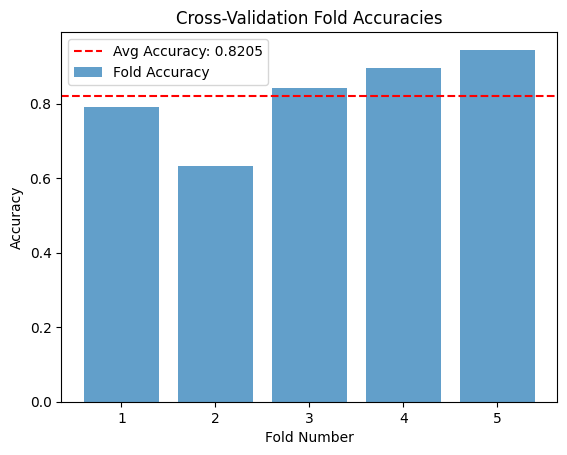

Mislabeled samples in Fold 3:
Empty DataFrame
Columns: [Be, B, Mg, Si, Ca, Sc, Ti, V, Cr, Mn, Co, Ni, Cu, Rb, Sr, Y, Zr, Nb, Cs, Ba, La, Ce, Pr, Nd, Sm, Eu, Gd, Tb, Dy, Ho, Er, Tm, Yb, Lu, Hf, Ta, Pb, Th, U]
Index: []

[0 rows x 39 columns]
True labels: Series([], Name: T, dtype: float64)
Predicted labels: []


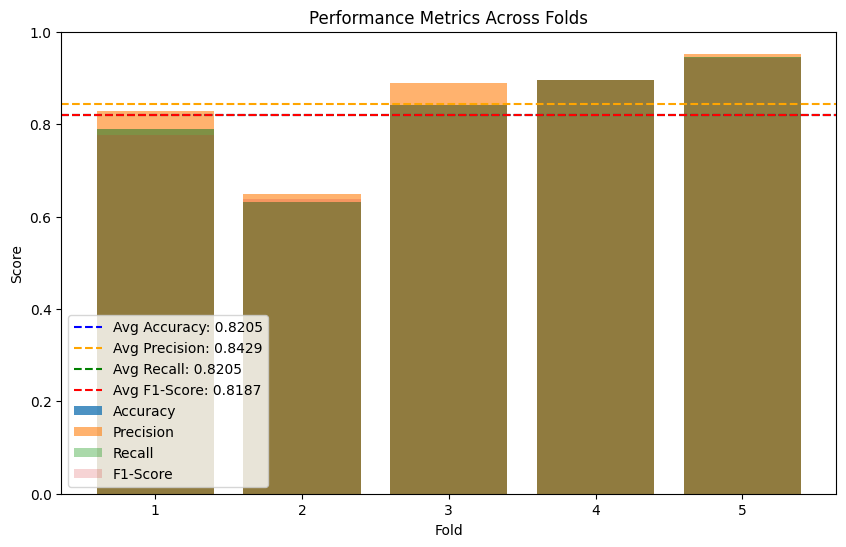

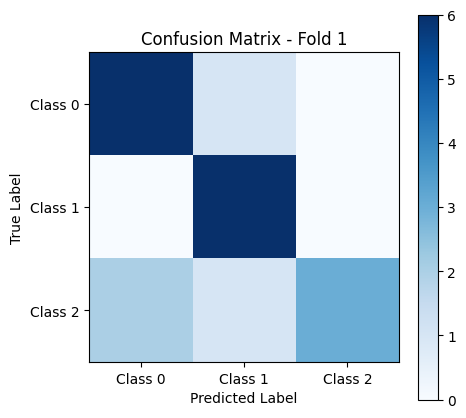

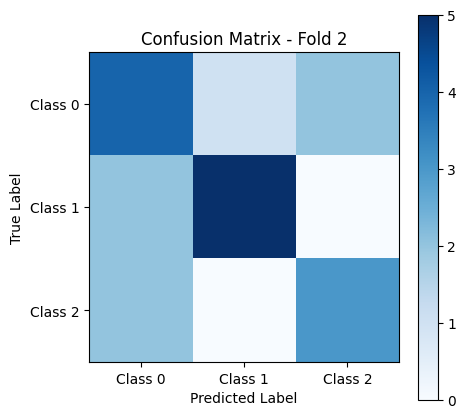

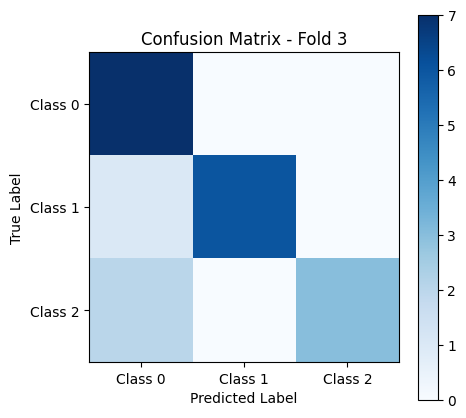

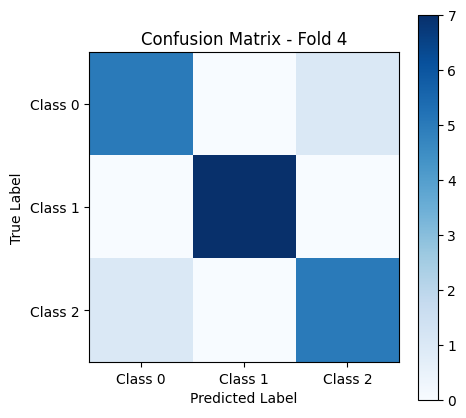

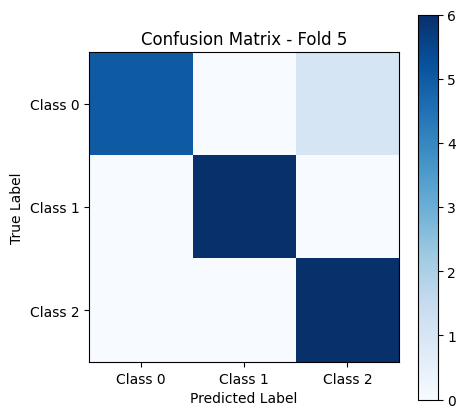

In [2]:

# Calling important libraries

# importing libraries like google drive
# pandas
# matplotlib and seaborn
# numpy

import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns


icpms.dtypes

icpms['T'] = icpms['T'].astype(float)

icpms.dtypes


#splitting the data

#for splitting the dataframes

from sklearn.model_selection import train_test_split, StratifiedKFold

# for calling the models
from sklearn.ensemble import RandomForestClassifier

from sklearn.linear_model import LogisticRegression

#for calling the model performance metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix



# Defining the dataframe into X features and y target label

X = icpms.drop(columns=['T'])
y = icpms['T']





#for splitting the dataframes

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,

                                                    stratify=y, #applying stratified splitting to ensure proportional representation of target classes in training and test sets.

                                                    random_state=42)



##########################################################


# for calling the models

from sklearn.linear_model import LogisticRegression

#for calling the model performance metrics

from sklearn.metrics import accuracy_score

# defining the function train_and_evaluate

# it takes the argument X_train_fold, y_train_fold, X_val_fold and y_val_fold

def train_and_evaluate(X_train_fold, y_train_fold, X_val_fold, y_val_fold):
    """
    it Train and evaluate the model on a single fold using Logistic Regression.
    """
    # Train the model

    model = LogisticRegression(random_state=42,
                               max_iter=1000)  # Increased max_iter for convergence

    model.fit(X_train_fold, y_train_fold)

    # Validate the model

    y_val_pred = model.predict(X_val_fold) # prediction on X_val_fold

    accuracy = accuracy_score(y_val_fold, y_val_pred) # where y_val_pred = model.predict(X_val_fold)

    return accuracy

###########################################################################################################################

#**Applying logistic regression to it with k fold cross validation**



from sklearn.model_selection import StratifiedKFold

# Placeholder for metrics

fold_precisions = []

fold_recalls = []

fold_f1_scores = []

fold_confusion_matrices = []

fold_accuracies = []

fold_models = []  # Store models for each fold

# Define Stratified K-Fold as kf where,

kf = StratifiedKFold(n_splits=5,
                     shuffle=True,
                     random_state=42)


# Loop through the folds
for fold, (train_index, val_index) in enumerate( kf.split( X_train, y_train ) ):

    # Split the data into training and validation subsets

    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]

    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    # Call the training function

    accuracy = train_and_evaluate(X_train_fold,
                                  y_train_fold,
                                  X_val_fold,
                                  y_val_fold)

    fold_accuracies.append(accuracy)

    # Train model and save it for later use

    model = LogisticRegression(random_state=42, max_iter=1000)

    model.fit(X_train_fold, y_train_fold)

    fold_models.append(model)  # Save the trained model

    print(f"Fold {fold + 1} Accuracy: {accuracy:.4f}")

    # Validate and calculate additional metrics
    y_val_pred = model.predict(X_val_fold)

    precision = precision_score(y_val_fold, y_val_pred, average="weighted")


    recall = recall_score(y_val_fold, y_val_pred, average="weighted")

    f1 = f1_score(y_val_fold, y_val_pred, average="weighted")

    confusion = confusion_matrix(y_val_fold, y_val_pred)

    fold_precisions.append(precision)

    fold_recalls.append(recall)

    fold_f1_scores.append(f1)

    fold_confusion_matrices.append(confusion)

    print(f"Fold {fold + 1} Metrics:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print(f"  Confusion Matrix:\n{confusion}\n")

# Calculate average metrics

avg_accuracy = sum(fold_accuracies) / len(fold_accuracies)

avg_precision = sum(fold_precisions) / len(fold_precisions)

avg_recall = sum(fold_recalls) / len(fold_recalls)

avg_f1_score = sum(fold_f1_scores) / len(fold_f1_scores)


# Calculate the average accuracy across all folds

print("Average Metrics Across All Folds:")

print(f"  Accuracy: {avg_accuracy:.4f}")

print(f"  Precision: {avg_precision:.4f}")

print(f"  Recall: {avg_recall:.4f}")

print(f"  F1-Score: {avg_f1_score:.4f}")



import matplotlib.pyplot as plt

# Calculate the average accuracy across all folds

avg_accuracy = sum(fold_accuracies) / len(fold_accuracies)

print(f"Average CV Accuracy: {avg_accuracy:.4f}")


# Visualization

folds = list(range(1,
                   len(fold_accuracies) + 1))

# Bar plot for individual fold accuracies

plt.bar(folds,
        fold_accuracies,
        alpha=0.7,
        label="Fold Accuracy")

plt.axhline(avg_accuracy,

            color= 'red',

            linestyle= '--',

            label= f"Avg Accuracy: {avg_accuracy:.4f}" )

# Add labels and title

plt.xlabel("Fold Number")

plt.ylabel("Accuracy")

plt.title("Cross-Validation Fold Accuracies")

plt.xticks(folds)

plt.legend()

# Show plot

plt.show()


# Use the model for Fold 3 to check for mislabeling
fold_3_model = fold_models[2]  # Model from Fold 3 (index starts at 0)

y_val_pred = fold_3_model.predict(X_val_fold)

# Identify mismatches in Fold 3

mismatches = X_val_fold[y_val_pred != y_val_fold]

mismatched_labels = y_val_fold[y_val_pred != y_val_fold]

# Display mismatched rows

print("Mislabeled samples in Fold 3:")

print(mismatches)

print("True labels:", mismatched_labels)

print("Predicted labels:", y_val_pred[y_val_pred != y_val_fold])



################################################################################


# Plotting metrics for each fold

folds = range(1, len(fold_accuracies) + 1)

plt.figure(figsize=(10, 6))

# Bar chart for Accuracy, Precision, Recall, and F1-Score

plt.bar(folds, fold_accuracies, alpha=0.8, label='Accuracy')

plt.bar(folds, fold_precisions, alpha=0.6, label='Precision')

plt.bar(folds, fold_recalls, alpha=0.4, label='Recall')

plt.bar(folds, fold_f1_scores, alpha=0.2, label='F1-Score')

plt.axhline(avg_accuracy, color='blue', linestyle='--', label=f'Avg Accuracy: {avg_accuracy:.4f}')

plt.axhline(avg_precision, color='orange', linestyle='--', label=f'Avg Precision: {avg_precision:.4f}')

plt.axhline(avg_recall, color='green', linestyle='--', label=f'Avg Recall: {avg_recall:.4f}')

plt.axhline(avg_f1_score, color='red', linestyle='--', label=f'Avg F1-Score: {avg_f1_score:.4f}')

# Labels and legend

plt.xlabel('Fold')

plt.ylabel('Score')

plt.title('Performance Metrics Across Folds')

plt.xticks(folds)

plt.legend()

plt.show()



for fold, confusion in enumerate(fold_confusion_matrices, start=1):

    plt.figure(figsize=(5, 5))

    plt.imshow(confusion, interpolation='nearest', cmap=plt.cm.Blues)

    plt.title(f'Confusion Matrix - Fold {fold}')

    plt.colorbar()

    # Dynamically set ticks and labels based on the number of classes

    classes = range(confusion.shape[0])

    plt.xticks(classes, labels=[f'Class {i}' for i in classes])

    plt.yticks(classes, labels=[f'Class {i}' for i in classes])


    plt.xlabel('Predicted Label')

    plt.ylabel('True Label')

    plt.show()








#**Random forest classifier**

Random Forest Model Accuracy: 0.83
Random Forest Model Precision: 0.84
Random Forest Model Recall: 0.83
Random Forest Model F1-Score: 0.83


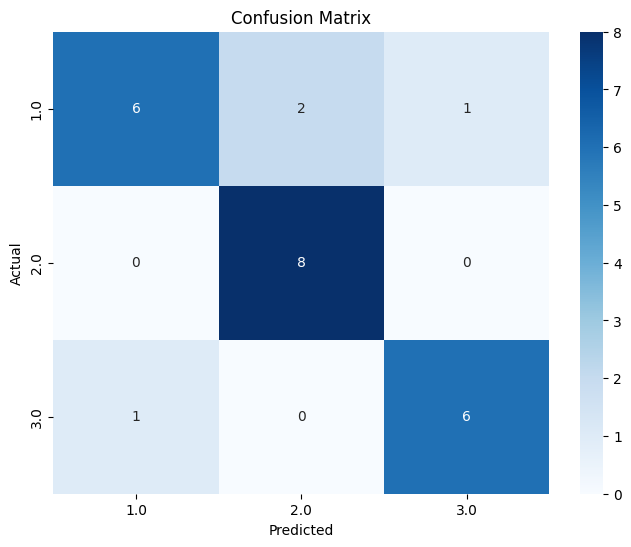

ROC curve and AUC not applicable for multiclass classification.


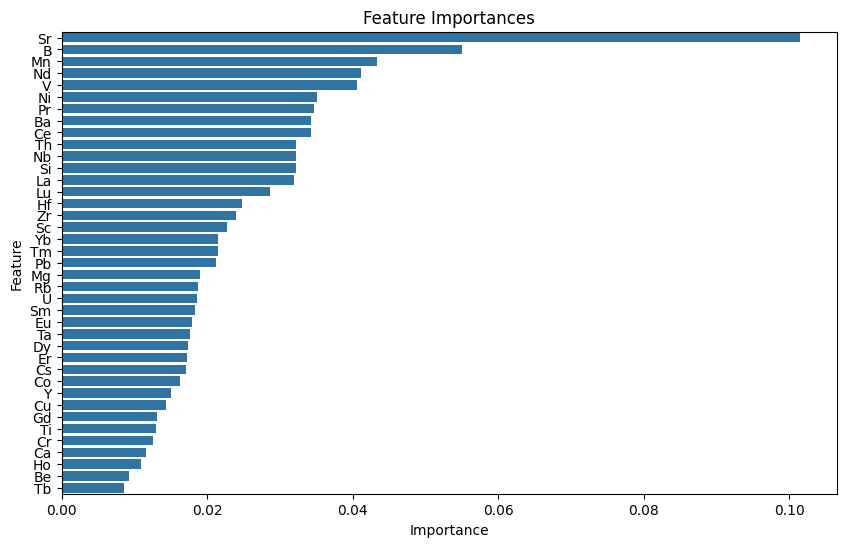

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

# Separate features and target
X = icpms.drop('T', axis=1)  # Features
y = icpms['T']               # Target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=48
)

# Define the Random Forest model
random_forest = RandomForestClassifier(
    n_estimators=200, max_depth=12, min_samples_split=6,
    class_weight='balanced', random_state=42
)

# Train the Random Forest model
random_forest.fit(X_train, y_train)

# Make predictions
y_pred = random_forest.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Random Forest Model Accuracy: {accuracy:.2f}")
print(f"Random Forest Model Precision: {precision:.2f}")
print(f"Random Forest Model Recall: {recall:.2f}")
print(f"Random Forest Model F1-Score: {f1:.2f}")

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC curve and AUC score (only for binary classification)
if len(np.unique(y)) == 2:
    y_prob = random_forest.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.2f})')
    plt.plot([0, 1], [0, 1], linestyle='--', color='grey')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.show()
else:
    print("ROC curve and AUC not applicable for multiclass classification.")

# Feature Importance
if hasattr(random_forest, 'feature_importances_'):
    feature_importances = pd.DataFrame({
        'Feature': X.columns,
        'Importance': random_forest.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importances)
    plt.title('Feature Importances')
    plt.show()


Cross-Validation Results:
Accuracy:
	Mean: 0.83
	Std: 0.04
Precision:
	Mean: 0.84
	Std: 0.03
Recall:
	Mean: 0.83
	Std: 0.04
F1:
	Mean: 0.83
	Std: 0.04

Test Set Evaluation:
Accuracy: 0.83
Precision: 0.84
Recall: 0.83
F1-Score: 0.83


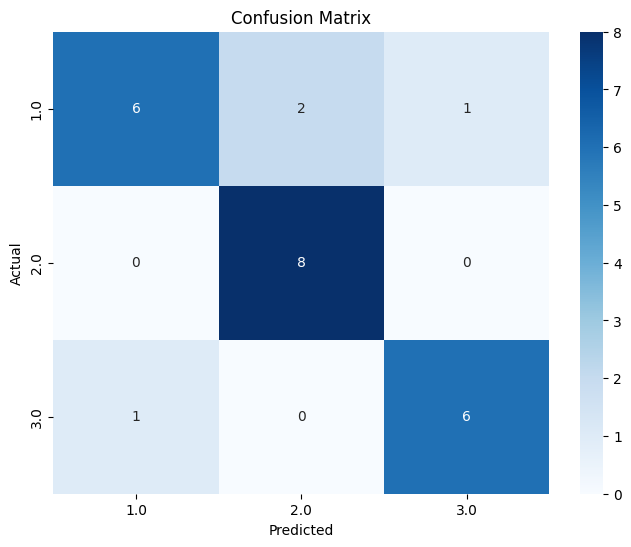

ROC curve and AUC not applicable for multiclass classification.


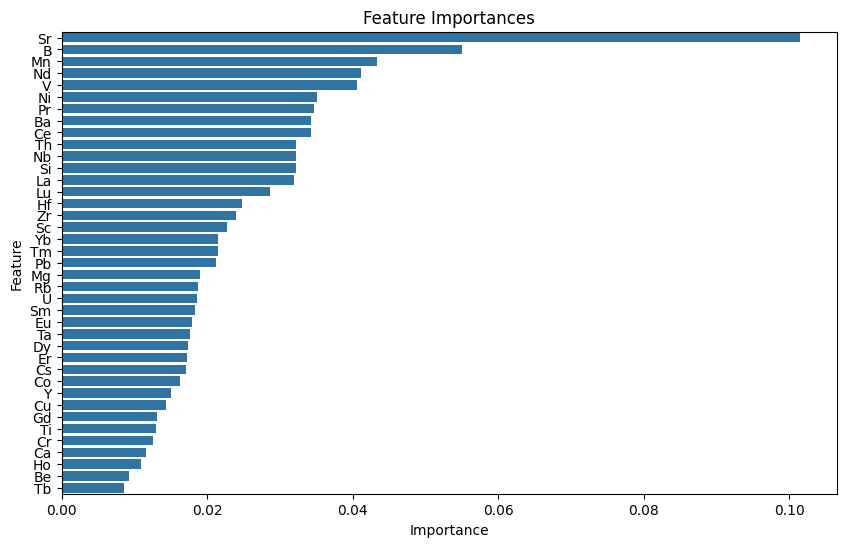

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve, make_scorer
)
import matplotlib.pyplot as plt
import seaborn as sns

# Separate features and target
X = icpms.drop('T', axis=1)  # Features
y = icpms['T']               # Target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=48
)

# Define the Random Forest model
random_forest = RandomForestClassifier(
    n_estimators=200, max_depth=12, min_samples_split=6,
    class_weight='balanced', random_state=42
)

# Perform cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='weighted'),
    'recall': make_scorer(recall_score, average='weighted'),
    'f1': make_scorer(f1_score, average='weighted')
}

cv_results = {metric: cross_val_score(random_forest, X, y, cv=cv, scoring=scoring[metric]) for metric in scoring}

# Print cross-validation results
print("Cross-Validation Results:")
for metric, scores in cv_results.items():
    print(f"{metric.capitalize()}:")
    print(f"\tMean: {np.mean(scores):.2f}")
    print(f"\tStd: {np.std(scores):.2f}")

# Train the Random Forest model
random_forest.fit(X_train, y_train)

# Make predictions
y_pred = random_forest.predict(X_test)

# Evaluate the model on the test set
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("\nTest Set Evaluation:")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC curve and AUC score (only for binary classification)
if len(np.unique(y)) == 2:
    y_prob = random_forest.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.2f})')
    plt.plot([0, 1], [0, 1], linestyle='--', color='grey')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.show()
else:
    print("ROC curve and AUC not applicable for multiclass classification.")

# Feature Importance
if hasattr(random_forest, 'feature_importances_'):
    feature_importances = pd.DataFrame({
        'Feature': X.columns,
        'Importance': random_forest.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importances)
    plt.title('Feature Importances')
    plt.show()


#**ensemble 1 logistic and random forest**

In [3]:
#ensemble model logistic and random forest

icpms['T'] = icpms['T'].astype(float)


#epma2 = pd.read_excel('/content/dataset epma preprocessed1.xlsx',
#                     sheet_name='Sheet1')

icpms.dtypes

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_auc_score, roc_curve)

import matplotlib.pyplot as plt
import seaborn as sns



# Separate features and target

X = icpms.drop('T', axis=1)  # Features

y = icpms['T']               # Target

# Split the data into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,

                                                    stratify=y, #applying stratified splitting to ensure proportional representation of target classes in training and test sets.

                                                    random_state=48)

# Define individual models
logistic = LogisticRegression(C=0.8,

                              penalty='l1',

                              solver='saga',

                              max_iter=200,

                              #class_weight='None'
                              )


random_forest = RandomForestClassifier(n_estimators=200,

                                      max_depth=12,

                                      min_samples_split=6,

                                      class_weight='balanced',

                                      random_state=42)


# Define hyperparameter grids
param_grid = {
    'lr__C': [0.1, 1, 10],
    'rf__n_estimators': [50, 100, 200],
    'rf__max_depth': [None, 10, 20],
}


# Create an ensemble model with max voting

voting_model = VotingClassifier(

    estimators=[('lr', logistic), ('rf', random_forest)],

    voting='hard'  # Hard voting: max voting
)


# Train the ensemble model

voting_model.fit(X_train, y_train)

# Make predictions

y_pred = voting_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Ensemble Model Accuracy: {accuracy:.2f}")



/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Ensemble Model Accuracy: 0.88


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



Performance metrics of Ensemble 1 model of LA-ICPMS test set:

Ensemble 1 Model  Accuracy: 0.88
Ensemble 1 Model Precision: 0.91
Ensemble 1 Model Recall: 0.88
Ensemble 1 Model F1-Score: 0.87

Classification Report of Ensemble 1 model of LA-ICPMS test set:

              precision    recall  f1-score   support

         1.0       0.75      1.00      0.86         9
         2.0       1.00      1.00      1.00         8
         3.0       1.00      0.57      0.73         7

    accuracy                           0.88        24
   macro avg       0.92      0.86      0.86        24
weighted avg       0.91      0.88      0.87        24



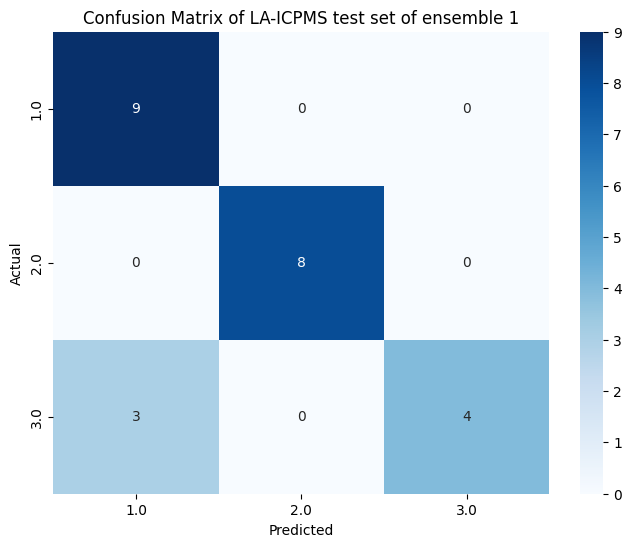

ROC curve and AUC not applicable for multiclass classification.


In [9]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the target column is float
icpms['T'] = icpms['T'].astype(float)

# Separate features and target
X = icpms.drop('T', axis=1)  # Features
y = icpms['T']               # Target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=48
)

# Define individual models
logistic = LogisticRegression(
    C=0.8, penalty='l1', solver='saga', max_iter=200
)

random_forest = RandomForestClassifier(
    n_estimators=200, max_depth=12, min_samples_split=6,
    class_weight='balanced', random_state=42
)

# Create an ensemble model with max voting
voting_model = VotingClassifier(
    estimators=[('lr', logistic), ('rf', random_forest)],
    voting='hard'
)

# Train the ensemble model
voting_model.fit(X_train, y_train)

# Make predictions
y_pred = voting_model.predict(X_test)

# Evaluate the model with metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')


print("\nPerformance metrics of Ensemble 1 model of LA-ICPMS test set:\n")
print(f"Ensemble 1 Model  Accuracy: {accuracy:.2f}")
print(f"Ensemble 1 Model Precision: {precision:.2f}")
print(f"Ensemble 1 Model Recall: {recall:.2f}")
print(f"Ensemble 1 Model F1-Score: {f1:.2f}")


# Classification report
print("\nClassification Report of Ensemble 1 model of LA-ICPMS test set:\n")
print(classification_report(y_test, y_pred))

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title('Confusion Matrix of LA-ICPMS test set of ensemble 1')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC curve (only for binary classification)
if len(np.unique(y)) == 2:
    y_prob = voting_model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.2f})')
    plt.plot([0, 1], [0, 1], linestyle='--', color='grey')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.show()
else:
    print("ROC curve and AUC not applicable for multiclass classification.")

# Feature Importance (for Random Forest)
if hasattr(random_forest, 'feature_importances_'):
    feature_importances = pd.DataFrame({
        'Feature': X.columns,
        'Importance': random_forest.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importances)
    plt.title('Feature Importances')
    plt.show()


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Cross-Validation Accuracy Scores: [0.70833333 0.625      0.66666667 0.95652174 0.7826087 ]
Mean CV Accuracy: 0.75 ± 0.12


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Ensemble Model Accuracy: 0.88
Ensemble Model Precision: 0.91
Ensemble Model Recall: 0.88
Ensemble Model F1-Score: 0.87


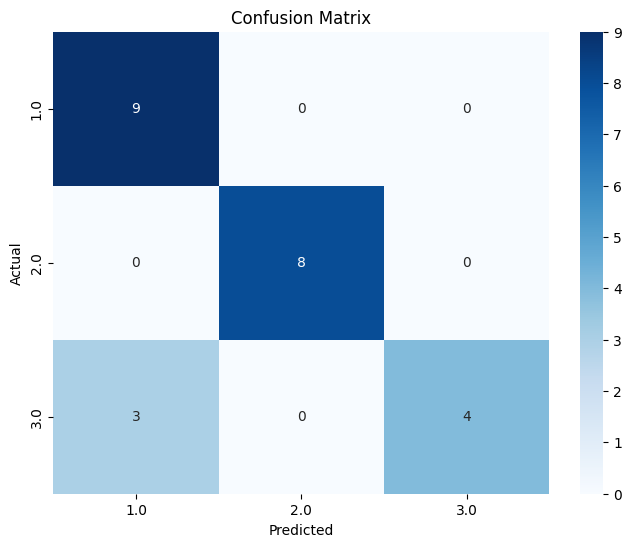

ROC curve and AUC not applicable for multiclass classification.


In [ ]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the target column is float
icpms['T'] = icpms['T'].astype(float)

# Separate features and target
X = icpms.drop('T', axis=1)  # Features
y = icpms['T']               # Target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=48
)

# Define individual models
logistic = LogisticRegression(
    C=0.8, penalty='l1', solver='saga', max_iter=200
)

random_forest = RandomForestClassifier(
    n_estimators=200, max_depth=12, min_samples_split=6,
    class_weight='balanced', random_state=42
)

# Create an ensemble model with max voting
voting_model = VotingClassifier(
    estimators=[('lr', logistic), ('rf', random_forest)],
    voting='hard'
)

# Perform cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=48)
cross_val_results = cross_val_score(voting_model, X, y, cv=cv, scoring='accuracy')

print("Cross-Validation Accuracy Scores:", cross_val_results)
print(f"Mean CV Accuracy: {np.mean(cross_val_results):.2f} \u00b1 {np.std(cross_val_results):.2f}")

# Train the ensemble model
voting_model.fit(X_train, y_train)

# Make predictions
y_pred = voting_model.predict(X_test)

# Evaluate the model with metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Ensemble Model Accuracy: {accuracy:.2f}")
print(f"Ensemble Model Precision: {precision:.2f}")
print(f"Ensemble Model Recall: {recall:.2f}")
print(f"Ensemble Model F1-Score: {f1:.2f}")

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC curve (only for binary classification)
if len(np.unique(y)) == 2:
    y_prob = voting_model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.2f})')
    plt.plot([0, 1], [0, 1], linestyle='--', color='grey')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.show()
else:
    print("ROC curve and AUC not applicable for multiclass classification.")

# Feature Importance (for Random Forest)
if hasattr(random_forest, 'feature_importances_'):
    feature_importances = pd.DataFrame({
        'Feature': X.columns,
        'Importance': random_forest.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importances)
    plt.title('Feature Importances')
    plt.show()


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Cross-Validation Accuracy Scores: [0.70833333 0.625      0.66666667 0.95652174 0.7826087 ]
Mean CV Accuracy: 0.75 ± 0.12


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Cross-Validation Precision Scores: [0.72916667 0.61805556 0.775      0.96135266 0.82608696]
Mean CV Precision: 0.78 ± 0.11


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Cross-Validation Recall Scores: [0.70833333 0.625      0.66666667 0.95652174 0.7826087 ]
Mean CV Recall: 0.75 ± 0.12


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Cross-Validation F1 Scores: [0.70075758 0.62009804 0.6744228  0.95635124 0.76231884]
Mean CV F1: 0.74 ± 0.12


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Ensemble Model Accuracy: 0.88
Ensemble Model Precision: 0.91
Ensemble Model Recall: 0.88
Ensemble Model F1-Score: 0.87


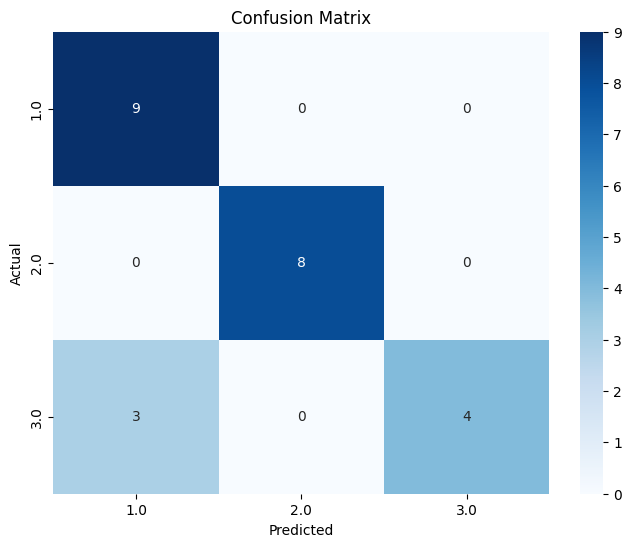

ROC curve and AUC not applicable for multiclass classification.


In [ ]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve, make_scorer
)
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the target column is float
icpms['T'] = icpms['T'].astype(float)

# Separate features and target
X = icpms.drop('T', axis=1)  # Features
y = icpms['T']               # Target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=48
)

# Define individual models
logistic = LogisticRegression(
    C=0.8, penalty='l1', solver='saga', max_iter=200
)

random_forest = RandomForestClassifier(
    n_estimators=200, max_depth=12, min_samples_split=6,
    class_weight='balanced', random_state=42
)

# Create an ensemble model with max voting
voting_model = VotingClassifier(
    estimators=[('lr', logistic), ('rf', random_forest)],
    voting='hard'
)

# Perform cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=48)
scores = {
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score, average='weighted'),
    'recall': make_scorer(recall_score, average='weighted'),
    'f1': make_scorer(f1_score, average='weighted')
}

cv_results = {}
for metric_name, metric_scorer in scores.items():
    cv_results[metric_name] = cross_val_score(voting_model, X, y, cv=cv, scoring=metric_scorer)
    print(f"Cross-Validation {metric_name.capitalize()} Scores: {cv_results[metric_name]}")
    print(f"Mean CV {metric_name.capitalize()}: {np.mean(cv_results[metric_name]):.2f} \u00b1 {np.std(cv_results[metric_name]):.2f}")

# Train the ensemble model
voting_model.fit(X_train, y_train)

# Make predictions
y_pred = voting_model.predict(X_test)

# Evaluate the model with metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Ensemble Model Accuracy: {accuracy:.2f}")
print(f"Ensemble Model Precision: {precision:.2f}")
print(f"Ensemble Model Recall: {recall:.2f}")
print(f"Ensemble Model F1-Score: {f1:.2f}")

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC curve (only for binary classification)
if len(np.unique(y)) == 2:
    y_prob = voting_model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.2f})')
    plt.plot([0, 1], [0, 1], linestyle='--', color='grey')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.show()
else:
    print("ROC curve and AUC not applicable for multiclass classification.")

# Feature Importance (for Random Forest)
if hasattr(random_forest, 'feature_importances_'):
    feature_importances = pd.DataFrame({
        'Feature': X.columns,
        'Importance': random_forest.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importances)
    plt.title('Feature Importances')
    plt.show()


# new logistic

Fold 1 Metrics:
  Accuracy: 0.7895
  Precision: 0.8289
  Recall: 0.7895
  F1-Score: 0.7759
  Confusion Matrix:
[[6 1 0]
 [0 6 0]
 [2 1 3]]

Fold 2 Metrics:
  Accuracy: 0.6316
  Precision: 0.6491
  Recall: 0.6316
  F1-Score: 0.6378
  Confusion Matrix:
[[4 1 2]
 [2 5 0]
 [2 0 3]]

Fold 3 Metrics:
  Accuracy: 0.8421
  Precision: 0.8895
  Recall: 0.8421
  F1-Score: 0.8409
  Confusion Matrix:
[[7 0 0]
 [1 6 0]
 [2 0 3]]

Fold 4 Metrics:
  Accuracy: 0.8947
  Precision: 0.8947
  Recall: 0.8947
  F1-Score: 0.8947
  Confusion Matrix:
[[5 0 1]
 [0 7 0]
 [1 0 5]]

Fold 5 Metrics:
  Accuracy: 0.9444
  Precision: 0.9524
  Recall: 0.9444
  F1-Score: 0.9441
  Confusion Matrix:
[[5 0 1]
 [0 6 0]
 [0 0 6]]

Average Metrics Across All Folds:
  Accuracy: 0.8205
  Precision: 0.8429
  Recall: 0.8205
  F1-Score: 0.8187


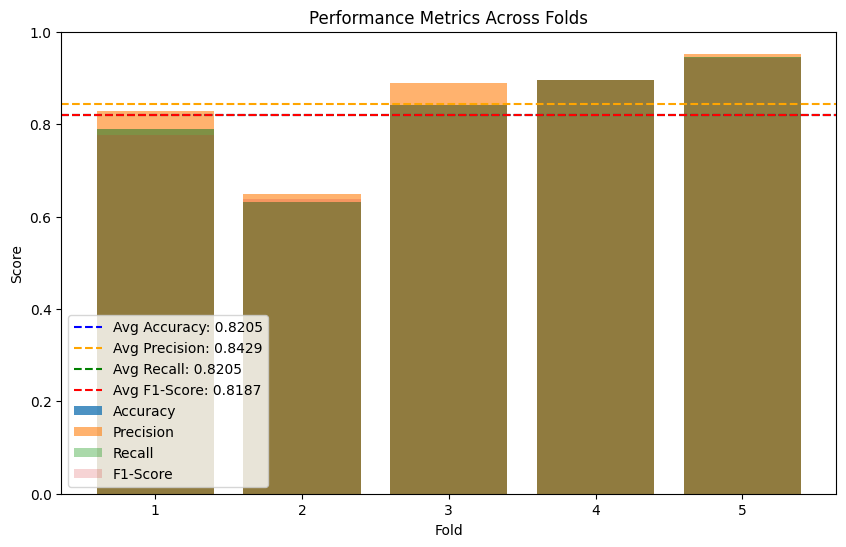

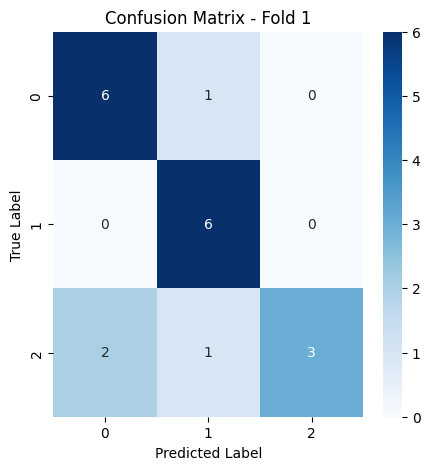

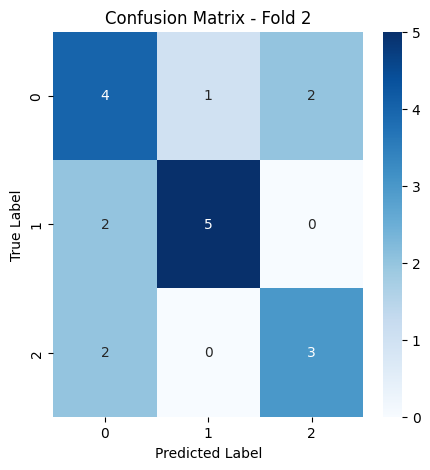

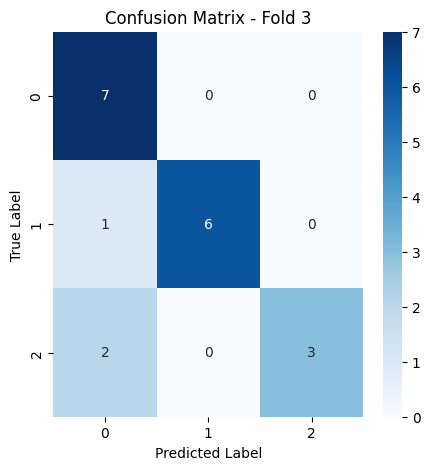

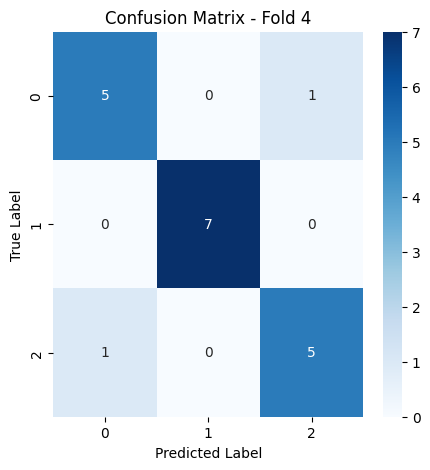

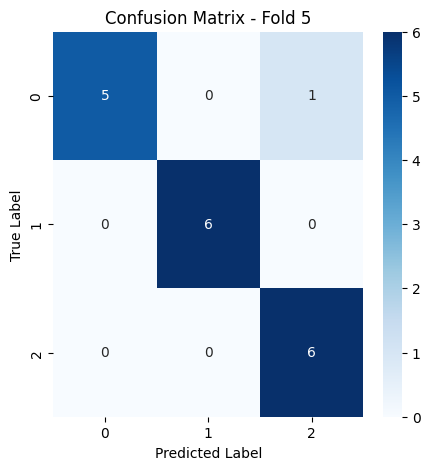

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)

# Define the dataframe into X features and y target label
X = icpms.drop(columns=['T'])
y = icpms['T']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Placeholder for metrics
fold_precisions = []
fold_recalls = []
fold_f1_scores = []
fold_confusion_matrices = []
fold_accuracies = []
fold_models = []  # Store models for each fold

# Define Stratified K-Fold
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Loop through the folds
for fold, (train_index, val_index) in enumerate(kf.split(X_train, y_train)):
    # Split the data into training and validation subsets
    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    # Train the model
    model = LogisticRegression(random_state=42, max_iter=1000)
    model.fit(X_train_fold, y_train_fold)
    fold_models.append(model)

    # Validate the model
    y_val_pred = model.predict(X_val_fold)
    accuracy = accuracy_score(y_val_fold, y_val_pred)
    precision = precision_score(y_val_fold, y_val_pred, average="weighted")
    recall = recall_score(y_val_fold, y_val_pred, average="weighted")
    f1 = f1_score(y_val_fold, y_val_pred, average="weighted")
    confusion = confusion_matrix(y_val_fold, y_val_pred)

    fold_accuracies.append(accuracy)
    fold_precisions.append(precision)
    fold_recalls.append(recall)
    fold_f1_scores.append(f1)
    fold_confusion_matrices.append(confusion)

    print(f"Fold {fold + 1} Metrics:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print(f"  Confusion Matrix:\n{confusion}\n")

# Calculate average metrics
avg_accuracy = np.mean(fold_accuracies)
avg_precision = np.mean(fold_precisions)
avg_recall = np.mean(fold_recalls)
avg_f1_score = np.mean(fold_f1_scores)

print("Average Metrics Across All Folds:")
print(f"  Accuracy: {avg_accuracy:.4f}")
print(f"  Precision: {avg_precision:.4f}")
print(f"  Recall: {avg_recall:.4f}")
print(f"  F1-Score: {avg_f1_score:.4f}")

# Visualization
folds = range(1, len(fold_accuracies) + 1)
plt.figure(figsize=(10, 6))
plt.bar(folds, fold_accuracies, alpha=0.8, label='Accuracy')
plt.bar(folds, fold_precisions, alpha=0.6, label='Precision')
plt.bar(folds, fold_recalls, alpha=0.4, label='Recall')
plt.bar(folds, fold_f1_scores, alpha=0.2, label='F1-Score')
plt.axhline(avg_accuracy, color='blue', linestyle='--', label=f'Avg Accuracy: {avg_accuracy:.4f}')
plt.axhline(avg_precision, color='orange', linestyle='--', label=f'Avg Precision: {avg_precision:.4f}')
plt.axhline(avg_recall, color='green', linestyle='--', label=f'Avg Recall: {avg_recall:.4f}')
plt.axhline(avg_f1_score, color='red', linestyle='--', label=f'Avg F1-Score: {avg_f1_score:.4f}')
plt.xlabel('Fold')
plt.ylabel('Score')
plt.title('Performance Metrics Across Folds')
plt.xticks(folds)
plt.legend()
plt.show()

for fold, confusion in enumerate(fold_confusion_matrices, start=1):
    plt.figure(figsize=(5, 5))
    sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - Fold {fold}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()


Fold 1 Metrics:
  Accuracy: 0.7895
  Precision: 0.8289
  Recall: 0.7895
  F1-Score: 0.7759
  Confusion Matrix:
[[6 1 0]
 [0 6 0]
 [2 1 3]]

Fold 2 Metrics:
  Accuracy: 0.6316
  Precision: 0.6491
  Recall: 0.6316
  F1-Score: 0.6378
  Confusion Matrix:
[[4 1 2]
 [2 5 0]
 [2 0 3]]

Fold 3 Metrics:
  Accuracy: 0.8421
  Precision: 0.8895
  Recall: 0.8421
  F1-Score: 0.8409
  Confusion Matrix:
[[7 0 0]
 [1 6 0]
 [2 0 3]]

Fold 4 Metrics:
  Accuracy: 0.8947
  Precision: 0.8947
  Recall: 0.8947
  F1-Score: 0.8947
  Confusion Matrix:
[[5 0 1]
 [0 7 0]
 [1 0 5]]

Fold 5 Metrics:
  Accuracy: 0.9444
  Precision: 0.9524
  Recall: 0.9444
  F1-Score: 0.9441
  Confusion Matrix:
[[5 0 1]
 [0 6 0]
 [0 0 6]]

Average Metrics Across All Folds:
  Accuracy: 0.8205
  Precision: 0.8429
  Recall: 0.8205
  F1-Score: 0.8187
Test Set Performance:
  Accuracy: 0.7917
  Precision: 0.7903
  Recall: 0.7917
  F1-Score: 0.7891
  Confusion Matrix:
[[7 0 2]
 [0 8 0]
 [3 0 4]]

Classification Report:
              precisio

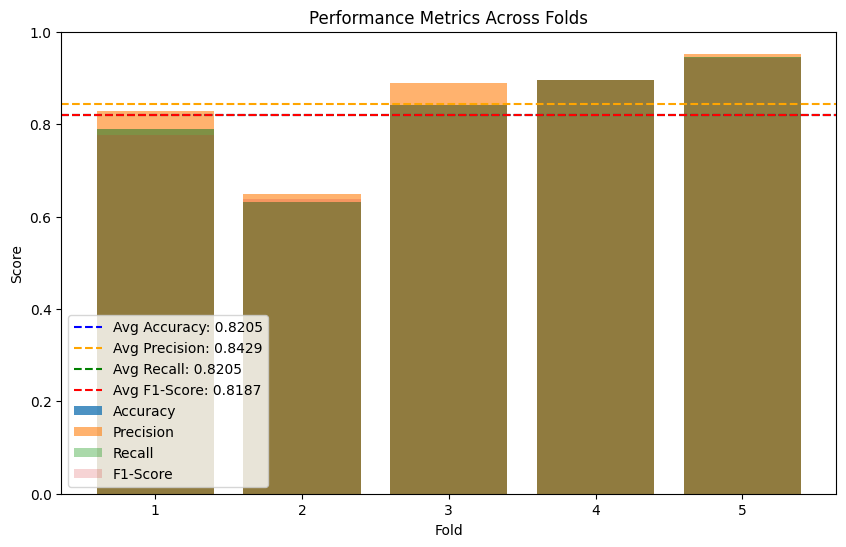

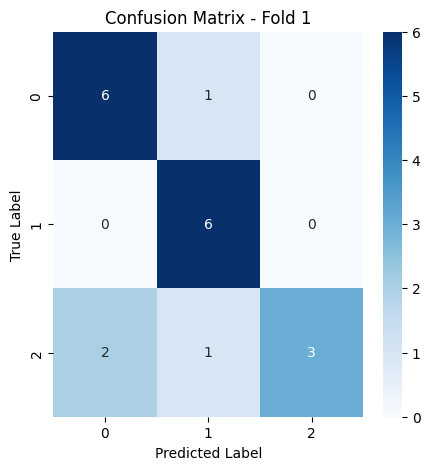

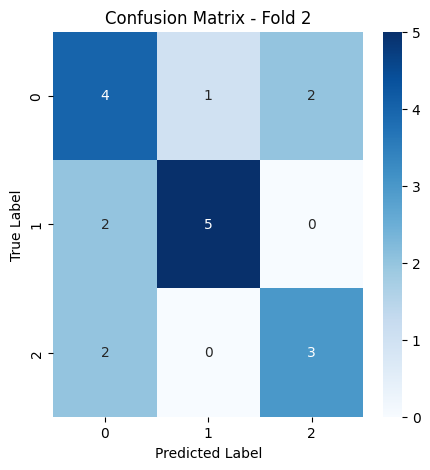

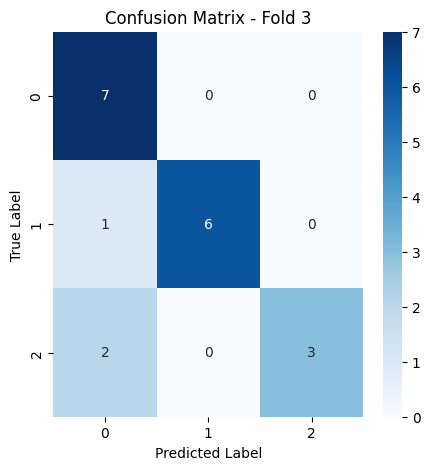

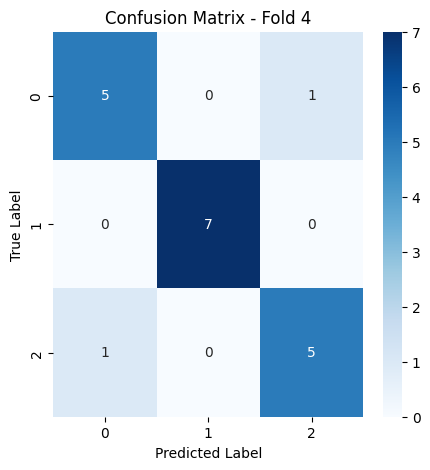

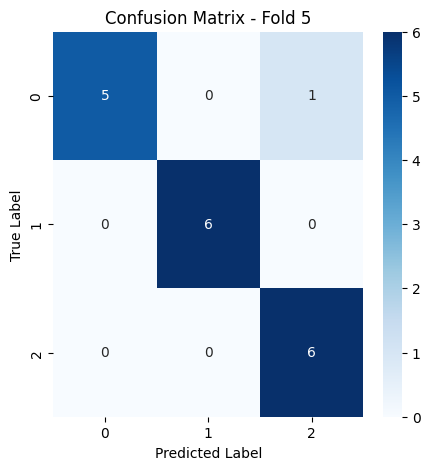

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
)

# Define the dataframe into X features and y target label
X = icpms.drop(columns=['T'])
y = icpms['T']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Placeholder for metrics
fold_precisions = []
fold_recalls = []
fold_f1_scores = []
fold_confusion_matrices = []
fold_accuracies = []
fold_models = []  # Store models for each fold

# Define Stratified K-Fold
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Loop through the folds
for fold, (train_index, val_index) in enumerate(kf.split(X_train, y_train)):
    # Split the data into training and validation subsets
    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    # Train the model
    model = LogisticRegression(random_state=42, max_iter=1000)
    model.fit(X_train_fold, y_train_fold)
    fold_models.append(model)

    # Validate the model
    y_val_pred = model.predict(X_val_fold)
    accuracy = accuracy_score(y_val_fold, y_val_pred)
    precision = precision_score(y_val_fold, y_val_pred, average="weighted")
    recall = recall_score(y_val_fold, y_val_pred, average="weighted")
    f1 = f1_score(y_val_fold, y_val_pred, average="weighted")
    confusion = confusion_matrix(y_val_fold, y_val_pred)

    fold_accuracies.append(accuracy)
    fold_precisions.append(precision)
    fold_recalls.append(recall)
    fold_f1_scores.append(f1)
    fold_confusion_matrices.append(confusion)

    print(f"Fold {fold + 1} Metrics:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print(f"  Confusion Matrix:\n{confusion}\n")

# Calculate average metrics
avg_accuracy = np.mean(fold_accuracies)
avg_precision = np.mean(fold_precisions)
avg_recall = np.mean(fold_recalls)
avg_f1_score = np.mean(fold_f1_scores)

print("Average Metrics Across All Folds:")
print(f"  Accuracy: {avg_accuracy:.4f}")
print(f"  Precision: {avg_precision:.4f}")
print(f"  Recall: {avg_recall:.4f}")
print(f"  F1-Score: {avg_f1_score:.4f}")

# Evaluate the final model on the test set
final_model = LogisticRegression(random_state=42, max_iter=1000)
final_model.fit(X_train, y_train)

y_test_pred = final_model.predict(X_test)
accuracy_test = accuracy_score(y_test, y_test_pred)
precision_test = precision_score(y_test, y_test_pred, average="weighted")
recall_test = recall_score(y_test, y_test_pred, average="weighted")
f1_test = f1_score(y_test, y_test_pred, average="weighted")
confusion_test = confusion_matrix(y_test, y_test_pred)

print("Test Set Performance:")
print(f"  Accuracy: {accuracy_test:.4f}")
print(f"  Precision: {precision_test:.4f}")
print(f"  Recall: {recall_test:.4f}")
print(f"  F1-Score: {f1_test:.4f}")
print(f"  Confusion Matrix:\n{confusion_test}\n")
print("Classification Report:")
print(classification_report(y_test, y_test_pred))

# Visualization
folds = range(1, len(fold_accuracies) + 1)
plt.figure(figsize=(10, 6))
plt.bar(folds, fold_accuracies, alpha=0.8, label='Accuracy')
plt.bar(folds, fold_precisions, alpha=0.6, label='Precision')
plt.bar(folds, fold_recalls, alpha=0.4, label='Recall')
plt.bar(folds, fold_f1_scores, alpha=0.2, label='F1-Score')
plt.axhline(avg_accuracy, color='blue', linestyle='--', label=f'Avg Accuracy: {avg_accuracy:.4f}')
plt.axhline(avg_precision, color='orange', linestyle='--', label=f'Avg Precision: {avg_precision:.4f}')
plt.axhline(avg_recall, color='green', linestyle='--', label=f'Avg Recall: {avg_recall:.4f}')
plt.axhline(avg_f1_score, color='red', linestyle='--', label=f'Avg F1-Score: {avg_f1_score:.4f}')
plt.xlabel('Fold')
plt.ylabel('Score')
plt.title('Performance Metrics Across Folds')
plt.xticks(folds)
plt.legend()
plt.show()

for fold, confusion in enumerate(fold_confusion_matrices, start=1):
    plt.figure(figsize=(5, 5))
    sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - Fold {fold}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()
